# Training a Diffusion Model from Scratch: DDPM Experiments on CIFAR-10

This project is a learning journey where I built and trained a Denoising Diffusion Probabilistic Model (DDPM) from scratch using PyTorch and the Diffusers library.

My goal is to understand the forward (noise adding) and backward (denoising) steps of diffusion models, observe the impact of model capacity, and analyze how images take shape throughout the training process. I used the CIFAR-10 dataset, which consists of 32x32 resolution, 3-channel (RGB) images.

In [5]:
from torchvision import transforms
from torch.utils.data import DataLoader
import torchvision.datasets as datasets

# Define the image transformation steps
image_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

# CIFAR10 DATASET
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=image_transform)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

100%|██████████| 170M/170M [00:02<00:00, 64.4MB/s] 


### Dataset Preview: Ground Truth (Class 1 - Automobile)
Before starting the training, let's take a look at some original images from the CIFAR-10 dataset. This gives us a "Ground Truth" reference to understand what the model is trying to learn. Since our experiments focus on generating automobiles, here are some real examples from Class 1.

Real examples from CIFAR-10 (Class 1: Automobile):


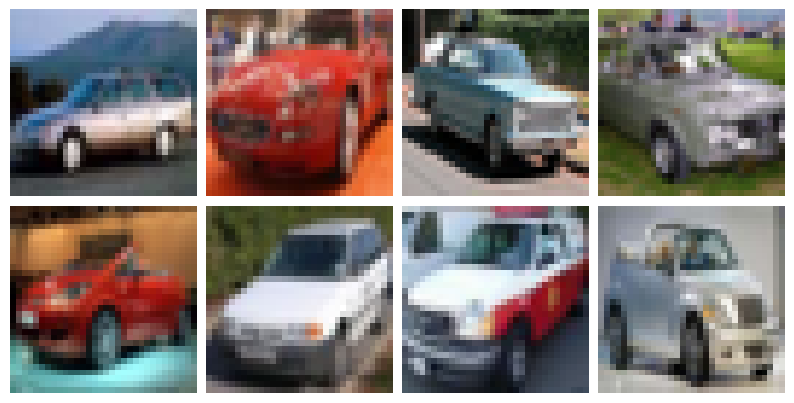

In [25]:
# Filter the dataset for class 1 (automobile)
automobile_indices = [i for i, label in enumerate(train_dataset.targets) if label == 1]
automobile_samples = torch.stack([train_dataset[i][0] for i in automobile_indices[:8]])

# Display real automobile images using our robust function
print("Real examples from CIFAR-10 (Class 1: Automobile):")
show_images_robust(automobile_samples, nrows=2)

### Model Architecture and Hyperparameters
For the model, I utilized the `UNet2DModel` from the Diffusers library. Since CIFAR-10 is a colored (RGB) dataset with complex backgrounds, I kept the model capacity relatively high:
- **Channels:** `(128, 128, 256, 512)`
- **Attention Layers:** Added to DownBlocks and UpBlocks to help the model capture relationships between distant pixels.
- **Scheduler:** A DDPM scheduler with a linear beta schedule was used for training stability. (We will switch to DDIM during the inference stage to significantly speed up generation).

In [6]:
from diffusers import UNet2DModel
from diffusers import DDPMScheduler
import torch

model_5 = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128, 128, 256, 512),

    down_block_types=(
        "DownBlock2D",        # 32x32
        "AttnDownBlock2D",    # 16x16
        "AttnDownBlock2D",    # 8x8
        "DownBlock2D",        # 4x4
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),

    attention_head_dim=64,
    num_class_embeds=10
)



scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_start=0.0001,
    beta_end=0.02,
    beta_schedule="linear",
    prediction_type="v_prediction",
)



In [7]:
import torch
from tqdm.auto import tqdm
from torch.nn import functional as F

num_epochs = 10
lr = 1e-4

device = "cuda" if torch.cuda.is_available() else "cpu"
model_5 = model_5.to(device)

optimizer = torch.optim.AdamW(model_5.parameters(), lr=lr, eps=1e-5)


batch_losses = []
epoch_losses = []

### Training Dynamics: Steps, Epochs, and Loss Tracking

In the context of diffusion models, training progress is typically evaluated in **steps** (iterations) rather than epochs. Given the CIFAR-10 training set of 50,000 images and a batch size of 128, a single epoch consists of 391 steps. Therefore, our 100-epoch training run translates to exactly **39,100 training steps**.

One of the key characteristics of training diffusion models is that instantaneous (per-batch) loss values are highly volatile. This happens because the difficulty of the denoising task varies wildly depending on the randomly selected timestep $t$ for each batch (e.g., predicting noise at $t=950$ is fundamentally different from $t=50$). 

To overcome this visual illusion and properly monitor the actual learning curve, I tracked and logged the **Average Epoch Loss** instead of relying on the fluctuating batch losses.

In [ ]:
for epoch in tqdm(range(num_epochs)):

    total_epoch_loss = 0.0

    for step, batch in tqdm(enumerate(train_dataloader),
                            total=len(train_dataloader)):

        clean_images, class_label = batch
        clean_images = clean_images.to(device)

        noise = torch.randn_like(clean_images).to(device)

        timesteps = torch.randint(
            0,
            scheduler.config.num_train_timesteps,
            (clean_images.shape[0],),
            device=device
        ).long()

        noisy_images = scheduler.add_noise(clean_images, noise, timesteps)

        noise_pred = model_5(
            noisy_images,
            timesteps,
            class_labels=class_label.to(device),
            return_dict=False
        )[0]

        alpha_t = scheduler.alphas_cumprod[timesteps].sqrt().view(-1, 1, 1, 1)
        sigma_t = (1 - scheduler.alphas_cumprod[timesteps]).sqrt().view(-1, 1, 1, 1)

        v = alpha_t * noise - sigma_t * clean_images

        loss = F.mse_loss(noise_pred, v)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_5.parameters(), 1.0)
        optimizer.step()

        batch_losses.append(loss.item())
        total_epoch_loss += loss.item()


    ortalama_loss = total_epoch_loss / len(train_dataloader)
    epoch_losses.append(ortalama_loss)

    print(f"  Epoch {epoch} | Avg Loss: {ortalama_loss:.5f}")


### Saving Checkpoints for Long-Term Training
Training a diffusion model on a dataset like CIFAR-10 is computationally expensive and exceeds the continuous execution limits of platforms like Kaggle. To manage this, I implemented a **checkpointing mechanism**. By saving the model's `state_dict`, optimizer state, and current epoch, I can resume the training process across multiple sessions without losing progress. This approach is essential for scaling the training toward the 500+ epochs required for high-fidelity image synthesis.

In [31]:
torch.save({
    "epoch": epoch,
    "model_state_dict": model_5.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": ortalama_loss
}, f"/kaggle/working/checkpoint_epoch_{epoch+85}.pth")

### Image Generation (Reverse Diffusion) and Class Conditioning
During the inference stage, we reverse the diffusion process. Starting from pure Gaussian noise, the model iteratively denoises the image step-by-step over exactly 1000 timesteps using the `DDPMScheduler`. 

While taking 1000 steps is computationally expensive and slow compared to faster sampling methods like DDIM, it provides highly stable results that perfectly align with the mathematical distribution learned during training. Additionally, I utilized **Conditional Generation** by passing `class_labels` to the model, guiding the UNet to denoise the random noise specifically into a target category (e.g., generating only "automobiles").

In [11]:
import torch
from tqdm.auto import tqdm


def generate_from_class(
    model,
    scheduler,
    class_to_generate,
    n_samples=8,
    device="cuda",
    use_ema=False,
):

    model_to_use.eval()

    sample = torch.randn(n_samples, 3, 32, 32).to(device)

    class_labels = torch.full(
        (n_samples,),
        class_to_generate,
        device=device,
        dtype=torch.long
    )

    scheduler.set_timesteps(1000)

    for t in tqdm(scheduler.timesteps):
        with torch.inference_mode():
            noise_pred = model_to_use(
                sample,
                t,
                class_labels=class_labels,
                return_dict=False
            )[0]

        sample = scheduler.step(
            noise_pred,
            t,
            sample
        ).prev_sample

    return sample.clamp(-1, 1) * 0.5 + 0.5

In [13]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def show_images_robust(images, nrows=2, figsize=(10, 5)):
    
    if isinstance(images, torch.Tensor):
        images = images.detach().cpu().numpy()


    if images.min() < 0:
        images = (images + 1.0) / 2.0
    

    images = np.clip(images, 0.0, 1.0)


    n_images = len(images)
    ncols = (n_images + nrows - 1) // nrows


    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, 
                             gridspec_kw={'wspace':0.05, 'hspace':0.05})
    

    axes = axes.flatten() if n_images > 1 else [axes]

    for i, ax in enumerate(axes):

        ax.axis("off")
        
        if i < n_images:
            img = images[i]
            

            if img.shape[0] in [1, 3]: 
                img = np.transpose(img, (1, 2, 0))
            
            if img.shape[-1] == 1:
                img = img.squeeze(-1)
                ax.imshow(img, cmap='gray')
            else:
                ax.imshow(img)

    plt.show()

* Generated "automobile" class images after 10 epoch

In [ ]:
checkpoint_path = path_10

checkpoint = torch.load(checkpoint_path, map_location=device)

model_5.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"]
loss = checkpoint["loss"]

  0%|          | 0/1000 [00:00<?, ?it/s]

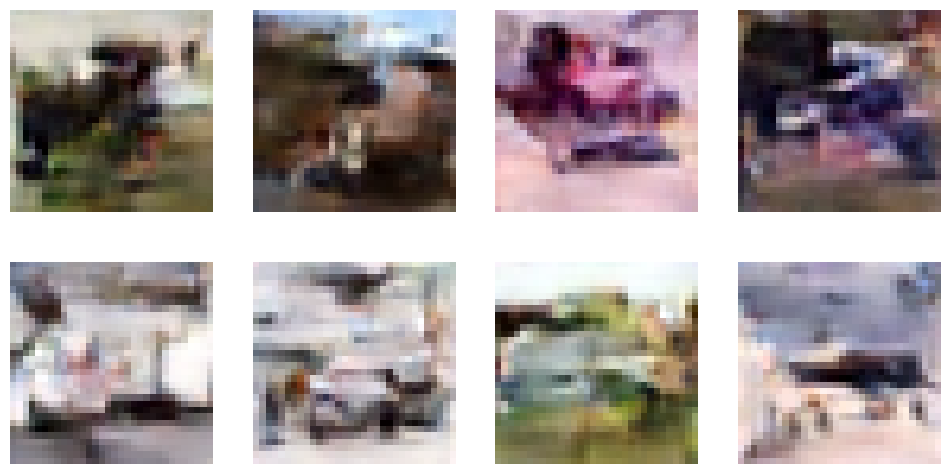

In [22]:
images_1 = generate_from_class(model_5, scheduler, class_to_generate=1, device=device)
show_images_robust(images_1, nrows=2)

* Generated "automobile" class images after 55 epoch

In [ ]:
checkpoint_path = path_55

checkpoint = torch.load(checkpoint_path, map_location=device)

model_5.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"]
loss = checkpoint["loss"]

  0%|          | 0/1000 [00:00<?, ?it/s]

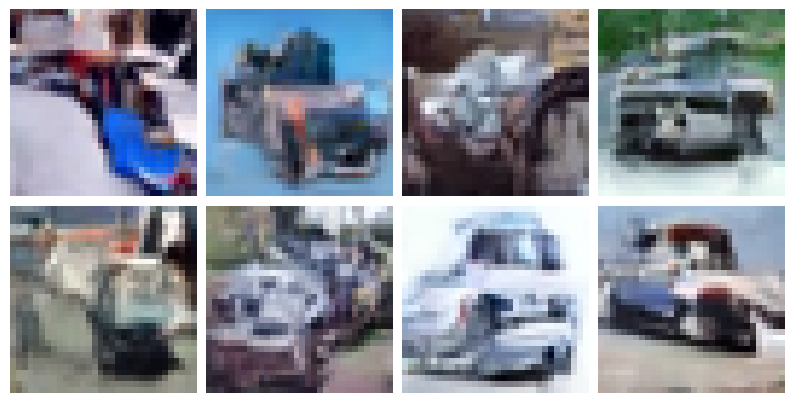

In [20]:
images_3 = generate_from_class(model_5, scheduler, class_to_generate=1, device=device)
show_images_robust(images_3, nrows=2)

* Generated "automobile" class images after 100 epoch

In [ ]:
checkpoint_path = path_100

checkpoint = torch.load(checkpoint_path, map_location=device)

model_5.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"]
loss = checkpoint["loss"]

  0%|          | 0/1000 [00:00<?, ?it/s]

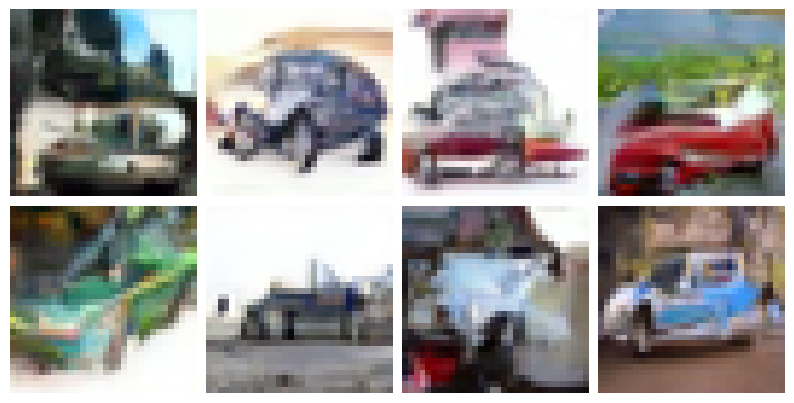

In [24]:
images_5 = generate_from_class(model_5, scheduler, class_to_generate=1, device=device)
show_images_robust(images_5, nrows=2)

### Model Evolution: Comparing Epochs 10, 55, and 100

As the training progressed, I analyzed the generated outputs at three different milestones:
1. **Epoch 10:** The model only grasped the general color palette of the dataset (e.g., greens, grays, and browns), but the shapes are just random color blobs.
2. **Epoch 55:** Dark spots and silhouettes detaching from the background started to appear. The model is learning spatial structures.
3. **Epoch 100:** Forms are now distinct. Basic outlines such as the curves of wheels or window areas of cars can be distinguished.

### 🛑 Why Stop at 100 Epochs? (Hardware & Computational Limits)
Although the model starts to break out of the underfitting phase at 100 epochs, the generated images are not yet crystal-clear. In the literature, achieving high-quality outputs (low FID scores) on CIFAR-10 requires training a diffusion model for **500 to 800 epochs** (approx. 400,000+ steps).

With the Kaggle T4 GPU limits (taking ~5 minutes per epoch), a 500-epoch training session would take about **40 hours**. Due to the platform's session time limits and hardware constraints, I am concluding this project at 100 Epochs as a successful **Proof of Concept**. It clearly demonstrates that the mathematical foundation, the training loop, and the inference logic are perfectly functional.